# Apply Predictions on CelebA Dataset to Filter Based on Hair Color

Apply interventions on hair color after sampling a "CausalCelebA" dataset

In [ ]:
%load_ext autoreload
%autoreload 2

In [15]:
import os
import re
from copy import copy
from pathlib import Path
from pprint import pprint

import PIL
import lightning as pl
import numpy as np
import torch
import lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader, random_split
import normflows as nf
from torchvision import transforms
from torchvision.utils import save_image, make_grid
import seaborn as sns
import matplotlib.pyplot as plt

from ciflows.datasets.causalceleba import CausalCelebA
from ciflows.datasets.multidistr import StratifiedSampler
from ciflows.datasets.causalceleba import CausalCelebAEmbedding
from ciflows.datasets.multidistr import StratifiedSampler, SynchronizedDataset

from torchvision.datasets import CelebA

from ciflows.datasets.causalceleba_scm.pretrained import MultiTaskResNet
from ciflows.eval import load_model
from ciflows.training import TopKModelSaver


In [5]:
root = Path("/Users/adam2392/pytorch_data/")
root = Path('/local/eb/adam2392/')
seed_offset = 1

# set seed
seed = 1234
np.random.seed(seed + seed_offset)
pl.seed_everything(seed + seed_offset, workers=True)

image_size = 128
latent_dim = 48
num_blocks_per_stage = 3
debug = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "cuda"

    # Get the index of the current device
    device_index = 7
    device = torch.device(f"cuda:{device_index}")
    print(f"Current CUDA device index: {device_index}")

    # Get the name of the current device
    device_name = torch.cuda.get_device_name(device_index)
    print(f"Current CUDA device name: {device_name}")

    num_devices = torch.cuda.device_count()
    device_names = [torch.cuda.get_device_name(i) for i in range(num_devices)]
    print('NUm devices: ', num_devices)
    print(device_names)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    accelerator = "mps"
else:
    device = torch.device("cpu")
    accelerator = "cpu"

print(f"Using device: {device}")
print(f"Using accelerator: {accelerator}")

Seed set to 1235


Current CUDA device index: 7
Current CUDA device name: NVIDIA H100 80GB HBM3
NUm devices:  8
['NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3']
Using device: cuda:7
Using accelerator: cuda


In [34]:
graph_type = 'chain'

model_path = Path('/local/eb/adam2392/CausalCelebA/pretrained/celeba_predictor_batch256_v1/celeba_predictor_batch256_v1.pt')
root_dir = Path('/local/eb/adam2392')
img_size = 128  # for loading in the OG image directory
image_size = 64
transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

causal_celeba_dataset = CausalCelebA(
    root=root_dir,
    graph_type=graph_type,
    transform=transform,
    img_size=img_size,
    fast_dev_run=False,  # Set to True for debugging
)


Processing intervention type: Haircolor


In [25]:
# Initialize the model, optimizer, and scheduler
model = MultiTaskResNet().to(device)
# model = torch.compile(model)
state_dict = torch.load(model_path, map_location=device)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

# print(model)

/tmp/ipykernel_2834477/861943933.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


<All keys matched successfully>

torch.Size([1, 4])
torch.Size([3, 64, 64])
torch.Size([1, 4])
torch.Size([3, 64, 64])
torch.Size([1, 4])
torch.Size([3, 64, 64])
torch.Size([1, 4])
torch.Size([3, 64, 64])
torch.Size([1, 4])
torch.Size([3, 64, 64])


AssertionError: 

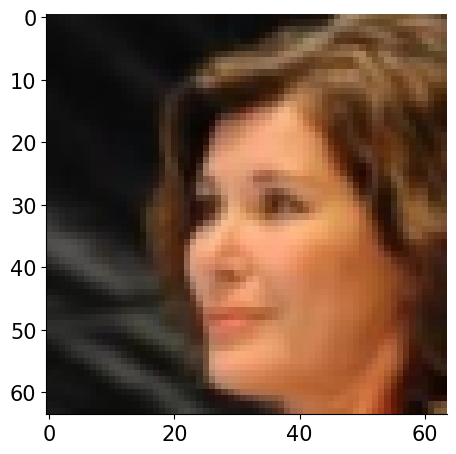

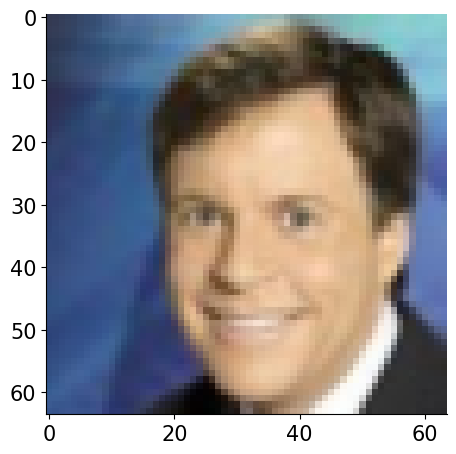

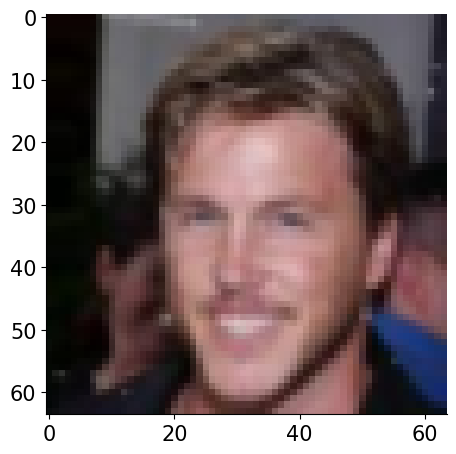

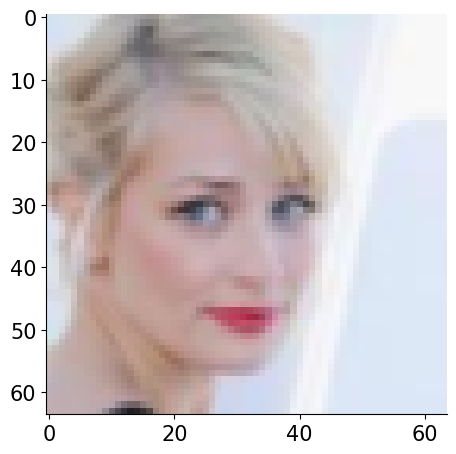

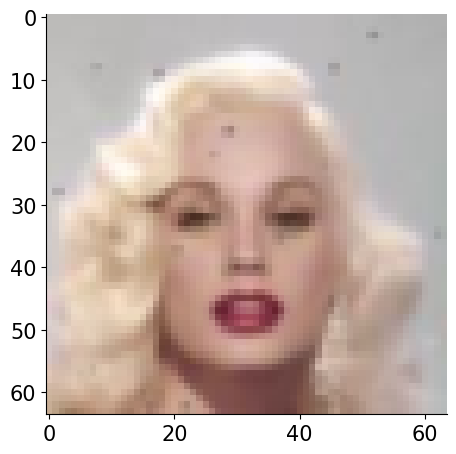

In [43]:
# iterate through dataset and flag images that are not predicted as what we want
import PIL.Image


distr_types = ["int_hair_0", "int_hair_1", "int_hair_2", "int_hair_3", "int_hair_4"]

for idx, distr_type in enumerate(distr_types):
    if idx == 0:
        hair_categories = ["Gray", "Brown"]
        hair_range = np.arange(2)
    elif idx == 1:
        hair_categories = ["Black", "Blond"]
        hair_range = np.arange(2)
    elif idx == 2:
        hair_categories = ["Black", "Brown"]
        hair_range = np.arange(2)
    elif idx == 3:
        hair_categories = ["Gray"]
        hair_range = np.arange(1)
    elif idx == 4:
        hair_categories = ["Blond"]
        hair_range = np.arange(1)

    distr_root = root / "CausalCelebA" / "chain" / f"dim{img_size}" / distr_type
    filename = distr_root / "causal_attrs.csv"
    attrs_df = pd.read_csv(filename)

    filename = distr_root / "meta_attrs.csv"
    meta_attrs_df = pd.read_csv(filename)

    # Find all files matching the pattern
    img_files = list(
        distr_root.rglob("sample_*.jpg")
    )  # Use glob for the current directory, rglob for recursive search
    img_files = sorted(
        [f for f in img_files if f.as_posix().endswith(".jpg")],
        key=lambda x: int(x.name.split("_")[1].split(".")[0]),  # Extract the numeric part
    )
    for jdx, filename in enumerate(img_files):
        # load in the file and apply transformation
        img = PIL.Image.open(filename)

        img = transform(img)
        (gender_logits, gender_probs), (hair_logits, hair_probs), (age_logits, age_probs) = model(torch.unsqueeze(img.to(device), 0))

        print(hair_probs.shape)
        print(img.shape)
        plt.figure()
        plt.imshow(torch.permute(img, (1, 2, 0)))

        if jdx > 3:
            assert False

torch.Size([3, 64, 64])
Black
/local/eb/adam2392/CausalCelebA/chain/dim128/int_hair_0/sample_3.jpg


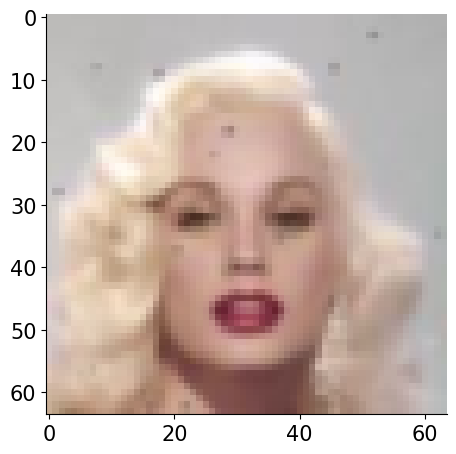

: 

In [ ]:
# img = torch.unsqueeze(img.to(device), 0)
print(img.shape)
(gender_logits, gender_probs), (hair_logits, hair_probs), (age_logits, age_probs) = model(torch.unsqueeze(img.to(device), 0))

hair_encoding = ["Black", "Blond", "Brown", "Gray"]
hair_prediction = torch.argmax(hair_probs)
print(hair_encoding[hair_prediction])
print(filename)
plt.imshow(torch.permute(img, (1, 2, 0)))